<a href="https://colab.research.google.com/github/mariaogl/ImplementacionCodigoAnalisisAlgoritmos/blob/main/Copia_de_ImplentacionCodigoAnalisisAlgoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##FUERZA BRUTA
arr = [1, -1, 2, -2, 1, -4, 2, -4, 1, -1]

ini, fin, suma = max_subarray_bruteforce(arr)

print("Inicio:", ini)
print("Fin:", fin)
print("Suma máxima:", suma)
print("Subarreglo máximo:", arr[ini:fin+1])
def max_subarray_bruteforce(arr):
    max_sum = -float('inf')
    best = (0, 0)
    n = len(arr)
    for i in range(n):
        s = 0
        for j in range(i, n):
            s += arr[j]
            if s > max_sum:
                max_sum = s
                best = (i, j)
    return best[0], best[1], max_sum


Inicio: 0
Fin: 2
Suma máxima: 2
Subarreglo máximo: [1, -1, 2]


# 1. Algoritmo de Fuerza Bruta

## Descripción
El algoritmo de fuerza bruta evalúa todos los subarreglos contiguos posibles del arreglo de entrada. Para cada subarreglo, calcula su suma y conserva el mayor valor encontrado. Este método garantiza encontrar la solución óptima, ya que no descarta ninguna combinación posible.

## Resultado obtenido
```
Inicio: 0
Fin: 2
Suma máxima: 2
Subarreglo: [1, -1, 2]
```

## Validación
```
1+(−1)+2=2
```

## Interpretación
El resultado es correcto, ya que el subarreglo identificado tiene una suma igual al máximo posible dentro del arreglo.

Es importante notar que este algoritmo puede devolver cualquier subarreglo óptimo válido. En este caso, devuelve un subarreglo de longitud mayor, aunque también existen soluciones más cortas con la misma suma.

In [ ]:
# =========================================================
# PROBLEMA DEL SUBARREGLO MÁXIMO
# ALGORITMO DIVIDE Y VENCERÁS + MAX CROSSING SUBARRAY
#
# OBJETIVO:
# Encontrar el subarreglo contiguo con la suma máxima
# usando el enfoque clásico de divide y vencerás.
#
# SALIDA DE LAS FUNCIONES:
# (indice_inicial, indice_final, suma_maxima)
# =========================================================


def max_crossing_subarray(arr, low, mid, high):
    """
    Calcula el mejor subarreglo que cruza el punto medio.

    Parámetros:
        arr  : lista de números
        low  : índice inicial del segmento
        mid  : índice medio del segmento
        high : índice final del segmento

    Retorna:
        (max_left, max_right, left_sum + right_sum)
    """

    # Buscar la mejor suma hacia la izquierda desde mid
    left_sum = float("-inf")
    suma_actual = 0
    max_left = mid

    for i in range(mid, low - 1, -1):
        suma_actual += arr[i]
        if suma_actual > left_sum:
            left_sum = suma_actual
            max_left = i

    # Buscar la mejor suma hacia la derecha desde mid + 1
    right_sum = float("-inf")
    suma_actual = 0
    max_right = mid + 1

    for j in range(mid + 1, high + 1):
        suma_actual += arr[j]
        if suma_actual > right_sum:
            right_sum = suma_actual
            max_right = j

    return max_left, max_right, left_sum + right_sum


def max_subarray_divide_and_conquer(arr, low, high):
    """
    Resuelve el problema del subarreglo máximo usando divide y vencerás.

    Parámetros:
        arr  : lista de números
        low  : índice inicial del segmento
        high : índice final del segmento

    Retorna:
        (indice_inicial, indice_final, suma_maxima)
    """

    # Caso base: un solo elemento
    if low == high:
        return low, high, arr[low]

    mid = (low + high) // 2

    # Resolver recursivamente la mitad izquierda
    left_low, left_high, left_sum = max_subarray_divide_and_conquer(arr, low, mid)

    # Resolver recursivamente la mitad derecha
    right_low, right_high, right_sum = max_subarray_divide_and_conquer(arr, mid + 1, high)

    # Resolver el caso cruzado
    cross_low, cross_high, cross_sum = max_crossing_subarray(arr, low, mid, high)

    # Comparar los tres casos
    if left_sum >= right_sum and left_sum >= cross_sum:
        return left_low, left_high, left_sum
    elif right_sum >= left_sum and right_sum >= cross_sum:
        return right_low, right_high, right_sum
    else:
        return cross_low, cross_high, cross_sum


# =========================================================
# PRUEBA CON TU ARREGLO
# =========================================================

arr = [1, -1, 2, -2, 1, -4, 2, -4, 1, -1]

inicio, fin, suma = max_subarray_divide_and_conquer(arr, 0, len(arr) - 1)

print("=== DIVIDE Y VENCERÁS ===")
print("Inicio:", inicio)
print("Fin:", fin)
print("Suma máxima:", suma)
print("Subarreglo máximo:", arr[inicio:fin + 1])




=== DIVIDE Y VENCERÁS ===
Inicio: 2
Fin: 2
Suma máxima: 2
Subarreglo máximo: [2]


# 2. Algoritmo Divide y Vencerás

## Descripción
El algoritmo divide el arreglo en dos mitades y resuelve recursivamente el problema en cada una de ellas. En cada nivel de la recursión se evalúan tres casos:

* El subarreglo máximo está completamente en la mitad izquierda
* El subarreglo máximo está completamente en la mitad derecha
* El subarreglo máximo cruza el punto medio

El resultado final corresponde al mayor valor entre estos tres casos.

## Resultado obtenido
```
Inicio: 2
Fin: 2
Suma máxima: 2
Subarreglo: [2]
```

## Validación
```
2
```

## Interpretación
El resultado es correcto y coincide con el valor máximo obtenido mediante fuerza bruta.

La diferencia en el subarreglo se debe a que existen múltiples soluciones óptimas en el arreglo. En este caso, el algoritmo selecciona el subarreglo más simple que cumple la condición de suma máxima.

# Análisis de resultados – Subarreglo máximo (Divide y Vencerás)

## Método
El algoritmo divide el arreglo en dos mitades y evalúa tres casos en cada paso:

* Subarreglo máximo en la izquierda
* Subarreglo máximo en la derecha
* Subarreglo máximo que cruza el centro (usando `max_crossing_subarray`)

La solución final es el máximo entre estos tres.

## Arreglo evaluado
```python
arr = [1, -1, 2, -2, 1, -4, 2, -4, 1, -1]
```

## Resultado principal
```
Inicio: 2
Fin: 2
Suma máxima: 2
Subarreglo: [2]
```
Este resultado es correcto, ya que 2 es la suma máxima posible en el arreglo.

Existen otros subarreglos con la misma suma (por ejemplo `[1, -1, 2]`), por lo que el algoritmo devuelve una solución válida, aunque no única.

## Resultado del caso cruzado
```
Subarreglo crossing: [1, -4, 2]
Suma: -1
```
Este valor no es el máximo global porque la función `max_crossing_subarray` solo evalúa subarreglos que cruzan el centro.

## Conclusión
* El algoritmo funciona correctamente al identificar la suma máxima = 2.
* La función `max_crossing_subarray` cumple su rol como caso auxiliar.
* El subarreglo máximo no cruza el centro, sino que está contenido en una de las mitades.

n = 10
  Merge Sort     : 0.00002043 segundos
  Insertion Sort : 0.00000642 segundos
--------------------------------------------------
n = 50
  Merge Sort     : 0.00007431 segundos
  Insertion Sort : 0.00004593 segundos
--------------------------------------------------
n = 100
  Merge Sort     : 0.00014026 segundos
  Insertion Sort : 0.00019902 segundos
--------------------------------------------------
n = 500
  Merge Sort     : 0.00082773 segundos
  Insertion Sort : 0.00532827 segundos
--------------------------------------------------
n = 1000
  Merge Sort     : 0.00182616 segundos
  Insertion Sort : 0.02121979 segundos
--------------------------------------------------
n = 5000
  Merge Sort     : 0.01094411 segundos
  Insertion Sort : 0.60255584 segundos
--------------------------------------------------

RESULTADOS FINALES
       n |       Merge Sort (s) |   Insertion Sort (s)
      10 |           0.00002043 |           0.00000642
      50 |           0.00007431 |           0.00

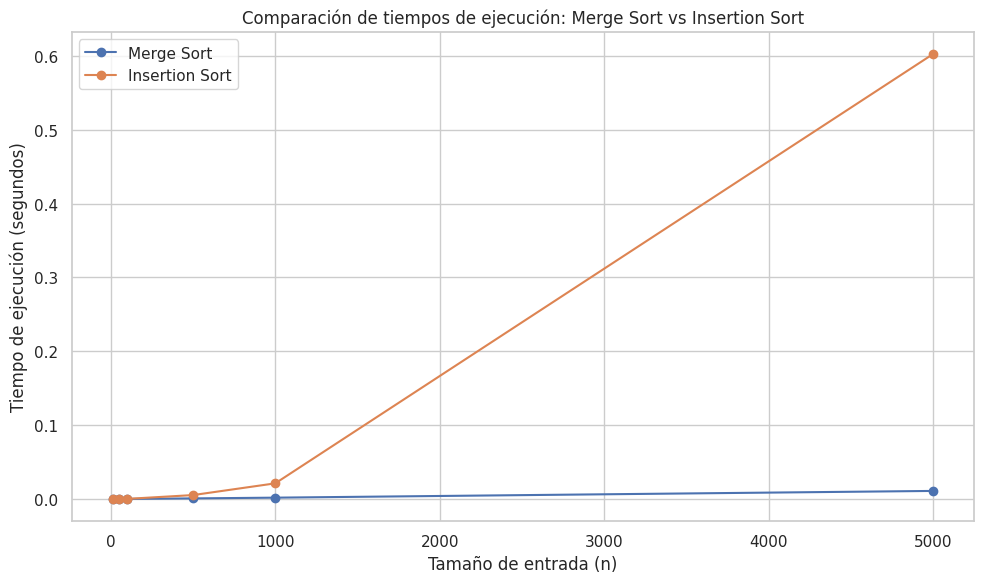

In [ ]:
# Implementar Merge Sort e Insertion Sort en Python,
# medir sus tiempos de ejecución para distintos tamaños
# de entrada y construir una gráfica comparativa.
# =========================================================

import random
import time
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. IMPLEMENTACIÓN DE MERGE SORT
# =========================================================

def merge_sort(arr):
    """
    Ordena una lista usando Merge Sort.
    Retorna una nueva lista ordenada.
    """
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)


def merge(left, right):
    """
    Mezcla dos listas ordenadas en una sola lista ordenada.
    """
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    # Agregar elementos restantes
    result.extend(left[i:])
    result.extend(right[j:])

    return result


# =========================================================
# 2. IMPLEMENTACIÓN DE INSERTION SORT
# =========================================================

def insertion_sort(arr):
    """
    Ordena una lista usando Insertion Sort.
    Retorna una nueva lista ordenada.
    """
    arr = arr.copy()

    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1

        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key

    return arr


# =========================================================
# 3. FUNCIÓN PARA MEDIR TIEMPO DE EJECUCIÓN
# =========================================================

def medir_tiempo(funcion, arr):
    """
    Mide el tiempo de ejecución de una función de ordenamiento.
    """
    inicio = time.perf_counter()
    funcion(arr)
    fin = time.perf_counter()
    return fin - inicio


# =========================================================
# 4. CONFIGURACIÓN DEL EXPERIMENTO
# =========================================================

# Tamaños de entrada solicitados en la guía
tamanos = [10, 50, 100, 500, 1000, 5000]

# Listas para guardar los tiempos
tiempos_merge = []
tiempos_insertion = []

# Semilla para reproducibilidad
random.seed(42)


# =========================================================
# 5. EJECUCIÓN DEL EXPERIMENTO
# =========================================================

for n in tamanos:
    # Generar un arreglo aleatorio de tamaño n
    arr = [random.randint(-10000, 10000) for _ in range(n)]

    # Medir Merge Sort
    tiempo_merge = medir_tiempo(merge_sort, arr)
    tiempos_merge.append(tiempo_merge)

    # Medir Insertion Sort
    tiempo_insertion = medir_tiempo(insertion_sort, arr)
    tiempos_insertion.append(tiempo_insertion)

    print(f"n = {n}")
    print(f"  Merge Sort     : {tiempo_merge:.8f} segundos")
    print(f"  Insertion Sort : {tiempo_insertion:.8f} segundos")
    print("-" * 50)


# =========================================================
# 6. MOSTRAR RESULTADOS EN TABLA
# =========================================================

print("\nRESULTADOS FINALES")
print("=" * 60)
print(f"{'n':>8} | {'Merge Sort (s)':>20} | {'Insertion Sort (s)':>20}")
print("=" * 60)

for n, tm, ti in zip(tamanos, tiempos_merge, tiempos_insertion):
    print(f"{n:>8} | {tm:>20.8f} | {ti:>20.8f}")


# =========================================================
# 7. GRÁFICA COMPARATIVA
# =========================================================

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
plt.plot(tamanos, tiempos_merge, marker='o', label='Merge Sort')
plt.plot(tamanos, tiempos_insertion, marker='o', label='Insertion Sort')

plt.title("Comparación de tiempos de ejecución: Merge Sort vs Insertion Sort")
plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.legend()
plt.tight_layout()
plt.show()

## Análisis de resultados

Los tiempos muestran dos comportamientos claramente distintos:

* Para tamaños pequeños (n = 10, 50), Insertion Sort es ligeramente más rápido. Esto es esperable porque tiene menor sobrecarga (no usa recursión ni mezcla de listas), mientras que Merge Sort incurre en costos adicionales de división y combinación.
* A partir de n ≈ 100, Merge Sort empieza a ser más eficiente. Desde este punto, el crecimiento cuadrático de Insertion Sort comienza a dominar.
* Para tamaños grandes (n ≥ 500), la diferencia se vuelve significativa. Por ejemplo:
    * En n = 1000, Insertion Sort es ~11 veces más lento.
    * En n = 5000, Insertion Sort es ~55 veces más lento.

Esto evidencia que Insertion Sort crece mucho más rápido en tiempo de ejecución, consistente con su complejidad O(n^2^), mientras que Merge Sort crece de forma más controlada, acorde a O(nlogn).

## Interpretación

Los resultados experimentales confirman el comportamiento teórico:

* Insertion Sort puede ser competitivo en tamaños pequeños debido a su simplicidad.
* Merge Sort escala mucho mejor a medida que aumenta el tamaño del problema.
* La gráfica (si la observas) debe mostrar una curva mucho más pronunciada para Insertion Sort.

## Conclusiones

* Merge Sort es significativamente más eficiente para tamaños de entrada grandes, debido a su complejidad O(nlogn), lo que se refleja en una menor tasa de crecimiento del tiempo de ejecución.
* Insertion Sort solo es competitivo en arreglos pequeños, donde su baja sobrecarga compensa su peor complejidad, pero pierde eficiencia rápidamente al aumentar n.
* Los resultados experimentales validan la teoría de complejidad, mostrando cómo el comportamiento real de los algoritmos coincide con su análisis asintótico.